In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [3]:

air = pd.read_csv("C:/Users/island/Desktop/beijingpm_25.csv")

air.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.00,1021.00,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.00,1020.00,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.00,1019.00,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.00,1019.00,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.00,1018.00,NW,12.97,0,0


In [4]:

print("行数：", air.shape[0])
print("列数：", air.shape[1])
print("列名：", air.columns.tolist())

行数： 43824
列数： 13
列名： ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']


In [5]:

if "pm2.5" in air.columns:
    air = air.rename(columns={"pm2.5": "PM2.5"})

air.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='str')

In [6]:
# 构造 datetime 时间字段
air["datetime"] = pd.to_datetime(
    air[["year", "month", "day", "hour"]],
    errors="coerce"
)

air[["datetime", "PM2.5"]].head()

,datetime,PM2.5
0,2010-01-01 00:00:00,NaN
1,2010-01-01 01:00:00,NaN
2,2010-01-01 02:00:00,NaN
3,2010-01-01 03:00:00,NaN
4,2010-01-01 04:00:00,NaN


In [7]:
air.isnull().sum().sort_values(ascending=False).head(10)

PM2.5    2067
No          0
year        0
month       0
day         0
hour        0
DEWP        0
TEMP        0
PRES        0
cbwd        0
dtype: int64

In [8]:

air = air.sort_values("datetime")


air["PM2.5"] = air["PM2.5"].interpolate()


air["PM2.5"] = air["PM2.5"].fillna(air["PM2.5"].median())

air["PM2.5"].isnull().sum()

np.int64(0)

In [9]:
pm25_stats = air["PM2.5"].describe()

pm25_stats

count   43824.00
mean       98.23
std        90.94
min         0.00
25%        30.00
50%        73.00
75%       136.00
max       994.00
Name: PM2.5, dtype: float64

In [10]:
print("PM2.5 平均值：", round(air["PM2.5"].mean(), 2))
print("PM2.5 中位数：", round(air["PM2.5"].median(), 2))
print("PM2.5 最大值：", round(air["PM2.5"].max(), 2))
print("PM2.5 最小值：", round(air["PM2.5"].min(), 2))
print("PM2.5 标准差：", round(air["PM2.5"].std(), 2))

PM2.5 平均值： 98.23
PM2.5 中位数： 73.0
PM2.5 最大值： 994.0
PM2.5 最小值： 0.0
PM2.5 标准差： 90.94


In [11]:

air["month_period"] = air["datetime"].dt.to_period("M")

monthly_pm25 = air.groupby("month_period")["PM2.5"].mean().reset_index()
monthly_pm25["month_period"] = monthly_pm25["month_period"].astype(str)

monthly_pm25.head()

,month_period,PM2.5
0,2010-01,86.69
1,2010-02,98.26
2,2010-03,98.89
3,2010-04,79.88
4,2010-05,86.91


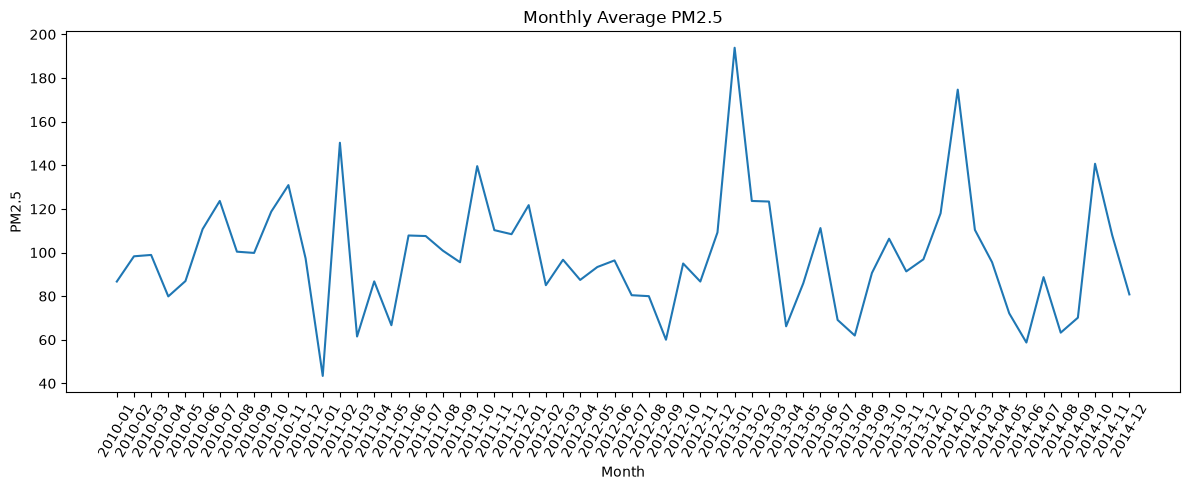

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_pm25["month_period"], monthly_pm25["PM2.5"])

plt.title("Monthly Average PM2.5")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [13]:
air["month"] = air["datetime"].dt.month

month_avg = air.groupby("month")["PM2.5"].mean().reset_index()

month_avg

,month,PM2.5
0,1,112.73
1,2,126.09
2,3,98.16
3,4,83.16
4,5,80.99
5,6,96.97
6,7,93.89
7,8,81.28
8,9,83.23
9,10,120.07


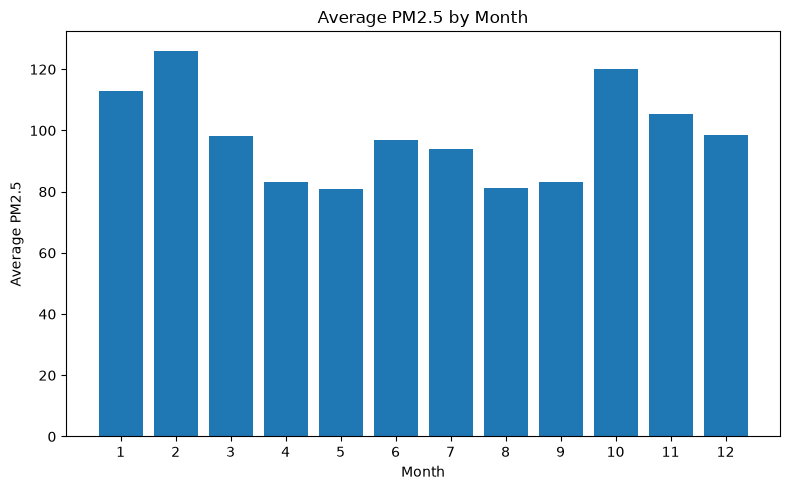

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(month_avg["month"], month_avg["PM2.5"])

plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

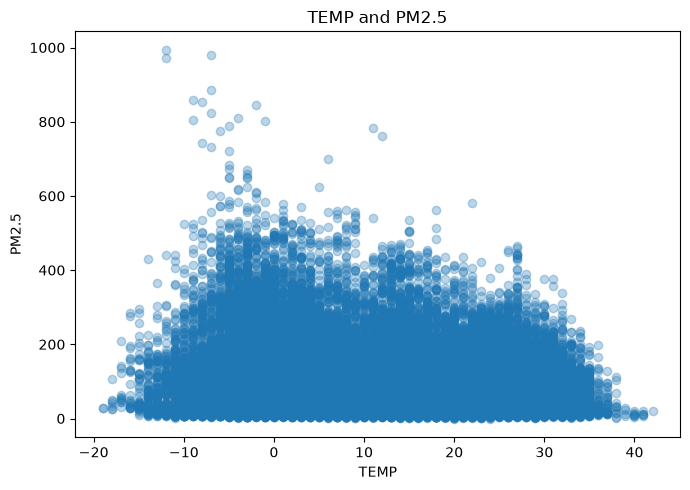

In [15]:
if "TEMP" in air.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(air["TEMP"], air["PM2.5"], alpha=0.3)

    plt.title("TEMP and PM2.5")
    plt.xlabel("TEMP")
    plt.ylabel("PM2.5")
    plt.tight_layout()
    plt.show()
else:
    print("数据中没有 TEMP 字段，无法绘制温度与 PM2.5 散点图。")

In [16]:
num_air = air.select_dtypes(include=["int64", "float64"])

corr_matrix = num_air.corr()

corr_matrix

,No,year,day,hour,PM2.5,DEWP,TEMP,PRES,Iws,Is,Ir
No,1.00,0.98,0.02,0.00,-0.01,0.05,0.08,-0.02,-0.06,-0.03,-0.02
year,0.98,1.00,0.00,-0.00,-0.01,0.00,0.05,-0.01,-0.06,-0.02,-0.02
day,0.02,0.00,1.00,-0.00,0.08,0.03,0.01,-0.01,-0.01,-0.04,0.00
hour,0.00,-0.00,-0.00,1.00,-0.02,-0.02,0.15,-0.04,0.06,-0.00,-0.01
PM2.5,-0.01,-0.01,0.08,-0.02,1.00,0.17,-0.09,-0.05,-0.25,0.02,-0.05
DEWP,0.05,0.00,0.03,-0.02,0.17,1.00,0.82,-0.78,-0.30,-0.03,0.13
TEMP,0.08,0.05,0.01,0.15,-0.09,0.82,1.00,-0.83,-0.15,-0.09,0.05
PRES,-0.02,-0.01,-0.01,-0.04,-0.05,-0.78,-0.83,1.00,0.19,0.07,-0.08
Iws,-0.06,-0.06,-0.01,0.06,-0.25,-0.30,-0.15,0.19,1.00,0.02,-0.01
Is,-0.03,-0.02,-0.04,-0.00,0.02,-0.03,-0.09,0.07,0.02,1.00,-0.01


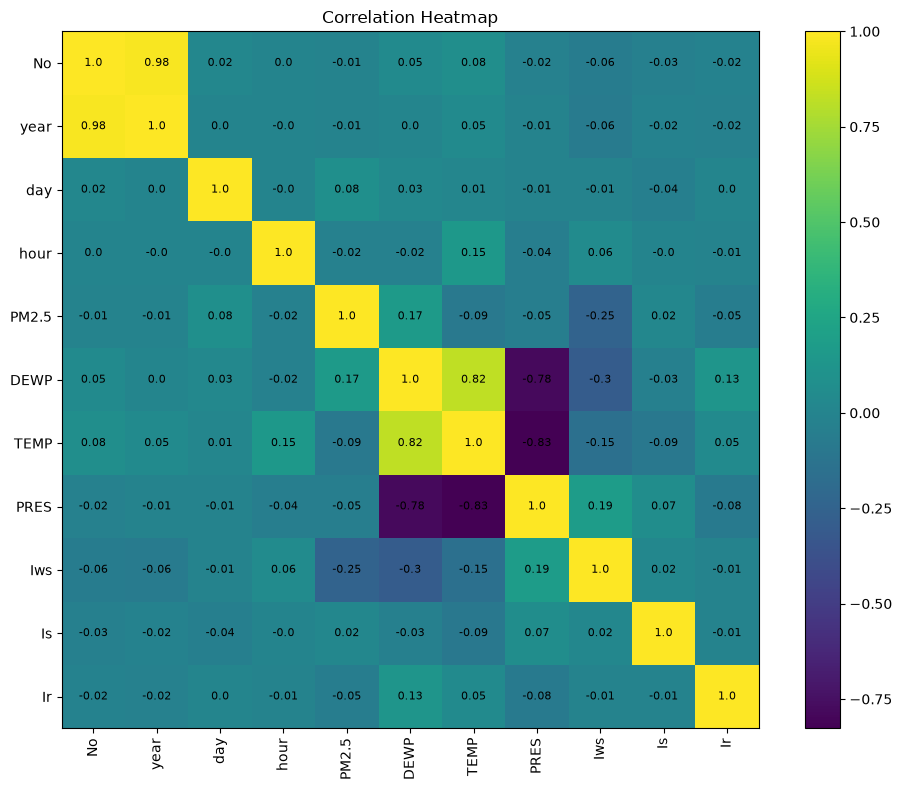

In [17]:
plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = round(corr_matrix.iloc[i, j], 2)
        plt.text(j, i, value, ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

相关性热力图可以展示多个数值变量之间的线性相关关系。颜色和数字可以帮助判断哪些变量与 PM2.5 的关系更强。

In [18]:
def get_season(month):
    if month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    else:
        return "Winter"


air["season"] = air["month"].apply(get_season)

season_pm25 = air.groupby("season")["PM2.5"].mean().reset_index()

season_pm25

,season,PM2.5
0,Autumn,103.09
1,Spring,87.48
2,Summer,90.64
3,Winter,112.03
